# Method 3 — Matrix Completion Synthetic Control (MC-SCM)
## Nuclear Norm Minimisation / Latent Factor Imputation

**What this notebook does:**
Matrix Completion SCM (Athey et al., 2021) reframes counterfactual estimation as a
matrix imputation problem. The full corridor × time panel is treated as a low-rank matrix.
NATCOR's post-treatment values are treated as "missing" and imputed via nuclear norm
minimisation (Singular Value Thresholding — SVT). This does NOT require donor weights at all
— it learns shared latent factors from the panel structure.

**Why it matters here:**
- Robust to missing data and measurement noise (common in freight panels)
- Exploits long-period structure (120 months) more fully than SCM
- Does not require the "convex hull" assumption (NATCOR need not be a blend of donors)
- Nuclear norm = convex relaxation of matrix rank → tractable with gradient-free methods

**Structure:**
1. Environment & shared utilities  
2. Data loading & full panel construction  
3. SVT algorithm & convergence analysis  
4. Blocked CV for lambda (nuclear norm penalty) selection  
5. Final MC-SCM counterfactual  
6. Rank diagnostics (singular values, effective rank)  
7. Validation A — In-time placebo (masked pre-period)  
8. Validation B — Subsampling CI (donor bootstrap)  
9. Validation C — Lambda sensitivity  
10. Figure panel  
11. Summary table & comparison  


In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 1 — Environment & Imports
# ═══════════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--', 'font.size': 10,
})
BLUE = '#0f3460'; RED = '#e94560'; GREY = '#aaaaaa'; GREEN = '#2ecc71'; AMBER = '#f39c12'
print("All imports successful.")


All imports successful.


## Shared Utility Functions

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2 — Shared Utility Functions
# ═══════════════════════════════════════════════════════════════════════════════

def svt(Y_obs, mask, lam, max_iter=2000, tol=1e-7, verbose=False):
    """
    Singular Value Thresholding (Mazumder, Hastie & Tibshirani 2010).
    
    Minimises:  0.5 * ||P_Omega(M - Y)||_F^2  +  lam * ||M||_*
    where P_Omega is the projection onto observed entries.
    
    Algorithm (projected gradient descent on nuclear norm):
      1. Start with M = Y (observed entries), 0 elsewhere
      2. Repeat:
         a. Soft-threshold the SVD of M by lam
         b. Re-project onto observed entries (plug back known values)
         c. Check convergence
    
    Parameters
    ----------
    Y_obs    : (T, N) matrix with observed values (unobserved = arbitrary)
    mask     : boolean (T, N) — True where observed
    lam      : nuclear norm penalty (larger = lower rank solution)
    """
    M = np.where(mask, Y_obs, 0.0)
    prev_M = M.copy()

    for it in range(max_iter):
        U, s, Vt = np.linalg.svd(M, full_matrices=False)
        s_thresh  = np.maximum(s - lam, 0.0)
        n_nonzero = np.sum(s_thresh > 0)
        M_new     = (U * s_thresh) @ Vt
        M_new     = np.where(mask, Y_obs, M_new)   # re-project observed

        change = np.linalg.norm(M_new - M, 'fro') / (np.linalg.norm(M, 'fro') + 1e-12)
        M = M_new

        if verbose and (it % 100 == 0 or it < 5):
            print(f"  iter {it:4d} | change={change:.2e} | rank={n_nonzero} | "
                  f"nuclear_norm={s_thresh.sum():.4f}")
        if change < tol:
            if verbose: print(f"  Converged at iter {it+1}")
            break

    return M, s_thresh, n_nonzero


def rmspe(a, b):
    return np.sqrt(np.mean((np.asarray(a) - np.asarray(b))**2))

def mape(a, b):
    a = np.asarray(a)
    return np.mean(np.abs((a - b) / np.where(a==0, 1e-10, a))) * 100

def effective_rank(singular_values, threshold=0.99):
    """Number of singular values explaining >= threshold of total variance."""
    sv = np.asarray(singular_values)
    sv2 = sv**2
    cum_var = np.cumsum(sv2) / sv2.sum()
    return int(np.searchsorted(cum_var, threshold)) + 1

print("Functions defined: svt, rmspe, mape, effective_rank")


Functions defined: svt, rmspe, mape, effective_rank


## Data Loading & Full Panel Construction

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3 — Data Loading & Panel Construction
# ═══════════════════════════════════════════════════════════════════════════════

CSV_PATH = '../data/corridor.csv'

df = pd.read_csv(CSV_PATH)
df['Date']        = df['Date'].astype(str).str.strip()
df['Corridor']    = df['Corridor'].astype(str).str.strip()
df['Date_period'] = pd.PeriodIndex(df['Date'], freq='M')

Y_COL       = 'Rail_Vol_mt'
TREATED     = 'NATCOR'
TREAT_START = pd.Period('2022-04', freq='M')
PRE_END     = TREAT_START - 1

wide     = df.pivot(index='Date_period', columns='Corridor', values=Y_COL).sort_index()
corridors = list(wide.columns)
donors   = [c for c in corridors if c != TREATED]
pre_idx  = wide.index[wide.index <= PRE_END]
post_idx = wide.index[wide.index >= TREAT_START]
T_pre    = len(pre_idx)
T_post   = len(post_idx)
T_total  = len(wide)
t_stamps = wide.index.to_timestamp()
treat_t  = TREAT_START.to_timestamp()

nat_col = corridors.index(TREATED)

# Full outcome matrix: shape (T_total, N_corridors)
Y_mat = wide.values.astype(float)
Y_all = wide[TREATED].values

print("─" * 55)
print(f"Panel matrix shape : {Y_mat.shape}  (T={T_total}, N={len(corridors)})")
print(f"Corridors (columns): {corridors}")
print(f"Treated unit col   : {nat_col} ({TREATED})")
print(f"Pre-period rows    : 0 → {T_pre-1}  ({T_pre} months)")
print(f"Post-period rows   : {T_pre} → {T_total-1}  ({T_post} months)")
print(f"Missing values     : {np.isnan(Y_mat).sum()}")
print()

# ── Mask: observe everything EXCEPT NATCOR post-treatment ─────────────────────
mask_full = np.ones(Y_mat.shape, dtype=bool)
mask_full[T_pre:, nat_col] = False  # NATCOR post entries = "missing counterfactual"

print(f"Observed entries   : {mask_full.sum()} / {Y_mat.size}")
print(f"Masked (to impute) : {(~mask_full).sum()} (NATCOR post-period)")
print()

# ── Baseline SVD of observed matrix (pre-period analysis) ─────────────────────
Y_pre_mat = Y_mat[:T_pre, :]
U0, s0, Vt0 = np.linalg.svd(Y_pre_mat, full_matrices=False)
print("Pre-period singular values:")
for i, sv in enumerate(s0):
    pct = sv**2 / np.sum(s0**2) * 100
    print(f"  σ_{i+1} = {sv:.6f}  ({pct:.1f}% of variance)")
print(f"  Effective rank (99% var): {effective_rank(s0)}")


───────────────────────────────────────────────────────
Panel matrix shape : (120, 2)  (T=120, N=2)
Corridors (columns): ['CAPE', 'NATCOR']
Treated unit col   : 1 (NATCOR)
Pre-period rows    : 0 → 86  (87 months)
Post-period rows   : 87 → 119  (33 months)
Missing values     : 0

Observed entries   : 207 / 240
Masked (to impute) : 33 (NATCOR post-period)

Pre-period singular values:
  σ_1 = 12.111389  (99.4% of variance)
  σ_2 = 0.917845  (0.6% of variance)
  Effective rank (99% var): 1


## Blocked CV for Lambda Selection

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 4 — Blocked CV for lambda (nuclear norm penalty)
# ═══════════════════════════════════════════════════════════════════════════════
# We hold out the LAST 25 pre-period observations of NATCOR and find the lambda
# that best predicts these held-out values (treating them as "missing").
# This is the strictest possible in-sample test: the model must extrapolate
# within the pre-period without ever seeing the validation targets.

val_window = 25    # hold out last 25 pre-period months
train_end  = T_pre - val_window

mask_cv = mask_full.copy()
mask_cv[train_end:T_pre, nat_col] = False   # also mask the validation window

lambda_grid = [0.001, 0.003, 0.005, 0.008, 0.010, 0.015, 0.020,
               0.030, 0.040, 0.050, 0.075, 0.100, 0.150, 0.200]

print(f"Blocked CV: train 0→{train_end-1} ({train_end} obs), validate {train_end}→{T_pre-1} ({val_window} obs)")
print(f"Lambda grid: {lambda_grid}")
print()

cv_records = []
for lam in lambda_grid:
    M_cv, s_cv, rank_cv = svt(Y_mat, mask_cv, lam=lam, verbose=False)
    val_true = Y_mat[train_end:T_pre, nat_col]
    val_pred = M_cv[train_end:T_pre, nat_col]
    val_err  = rmspe(val_true, val_pred)
    tr_true  = Y_mat[:train_end, nat_col]
    tr_pred  = M_cv[:train_end, nat_col]
    tr_err   = rmspe(tr_true, tr_pred)
    cv_records.append({'lambda': lam, 'val_RMSPE': round(val_err, 6),
                       'train_RMSPE': round(tr_err, 6), 'rank': int(rank_cv)})
    print(f"  λ={lam:6.3f}  val_RMSPE={val_err:.6f}  train_RMSPE={tr_err:.6f}  rank={rank_cv}")

cv_df = pd.DataFrame(cv_records)
best_row = cv_df.loc[cv_df['val_RMSPE'].idxmin()]
BEST_LAM = best_row['lambda']
print()
print(f"★ Best lambda: {BEST_LAM}  (val_RMSPE={best_row['val_RMSPE']:.6f}, rank={int(best_row['rank'])})")


Blocked CV: train 0→61 (62 obs), validate 62→86 (25 obs)
Lambda grid: [0.001, 0.003, 0.005, 0.008, 0.01, 0.015, 0.02, 0.03, 0.04, 0.05, 0.075, 0.1, 0.15, 0.2]

  λ= 0.001  val_RMSPE=0.584706  train_RMSPE=0.000000  rank=2
  λ= 0.003  val_RMSPE=0.376308  train_RMSPE=0.000000  rank=2
  λ= 0.005  val_RMSPE=0.226285  train_RMSPE=0.000000  rank=2
  λ= 0.008  val_RMSPE=0.125105  train_RMSPE=0.000000  rank=2
  λ= 0.010  val_RMSPE=0.120316  train_RMSPE=0.000000  rank=2
  λ= 0.015  val_RMSPE=0.126747  train_RMSPE=0.000000  rank=2
  λ= 0.020  val_RMSPE=0.127389  train_RMSPE=0.000000  rank=2
  λ= 0.030  val_RMSPE=0.127422  train_RMSPE=0.000000  rank=2
  λ= 0.040  val_RMSPE=0.127424  train_RMSPE=0.000000  rank=2
  λ= 0.050  val_RMSPE=0.127425  train_RMSPE=0.000000  rank=2
  λ= 0.075  val_RMSPE=0.127426  train_RMSPE=0.000000  rank=2
  λ= 0.100  val_RMSPE=0.127427  train_RMSPE=0.000000  rank=2
  λ= 0.150  val_RMSPE=0.127428  train_RMSPE=0.000000  rank=2
  λ= 0.200  val_RMSPE=0.127428  train_RMSPE=0.0

## Final MC-SCM Counterfactual

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5 — Final MC-SCM: fit on full observation mask
# ═══════════════════════════════════════════════════════════════════════════════

print(f"Fitting MC-SCM with λ={BEST_LAM} on full observation mask...")
M_final, sv_final, rank_final = svt(Y_mat, mask_full, lam=BEST_LAM, verbose=True)

# Counterfactual = imputed NATCOR values in post-period
cf_mc    = M_final[:, nat_col]
gap_mc   = Y_all - cf_mc

mc_pre_r  = rmspe(Y_all[:T_pre],  cf_mc[:T_pre])
mc_post_r = rmspe(Y_all[T_pre:],  cf_mc[T_pre:])
mc_ratio  = mc_post_r / mc_pre_r
mc_cum    = gap_mc[T_pre:].sum()
mc_avg    = gap_mc[T_pre:].mean()
mc_mape   = mape(Y_all[T_pre:], cf_mc[T_pre:])

print()
print("═" * 55)
print("MC-SCM RESULTS")
print("═" * 55)
print(f"Lambda (CV-selected)    : {BEST_LAM}")
print(f"Effective rank          : {rank_final}")
print(f"Singular values (used)  : {sv_final[sv_final > 0].round(4)}")
print()
print(f"Pre-period RMSPE        : {mc_pre_r:.6f}")
print(f"Post-period RMSPE       : {mc_post_r:.6f}")
print(f"Post/Pre ratio          : {mc_ratio:.4f}")
print(f"Cumulative effect       : {mc_cum:.4f} MT")
print(f"Average monthly effect  : {mc_avg:.4f} MT/month")
print(f"Post MAPE               : {mc_mape:.2f}%")


Fitting MC-SCM with λ=0.01 on full observation mask...
  iter    0 | change=4.20e-04 | rank=2 | nuclear_norm=15.9962
  iter    1 | change=4.19e-04 | rank=2 | nuclear_norm=15.9931
  iter    2 | change=4.19e-04 | rank=2 | nuclear_norm=15.9901
  iter    3 | change=4.19e-04 | rank=2 | nuclear_norm=15.9870
  iter    4 | change=4.19e-04 | rank=2 | nuclear_norm=15.9840
  iter  100 | change=3.95e-04 | rank=2 | nuclear_norm=15.7074
  iter  200 | change=3.68e-04 | rank=2 | nuclear_norm=15.4535
  iter  300 | change=3.37e-04 | rank=2 | nuclear_norm=15.2354
  iter  400 | change=3.03e-04 | rank=2 | nuclear_norm=15.0543
  iter  500 | change=2.64e-04 | rank=2 | nuclear_norm=14.9104
  iter  600 | change=2.23e-04 | rank=2 | nuclear_norm=14.8032
  iter  700 | change=1.80e-04 | rank=2 | nuclear_norm=14.7293
  iter  800 | change=1.38e-04 | rank=2 | nuclear_norm=14.6829
  iter  900 | change=1.02e-04 | rank=2 | nuclear_norm=14.6563
  iter 1000 | change=7.22e-05 | rank=2 | nuclear_norm=14.6424
  iter 1100 | c

## Rank & Singular Value Diagnostics

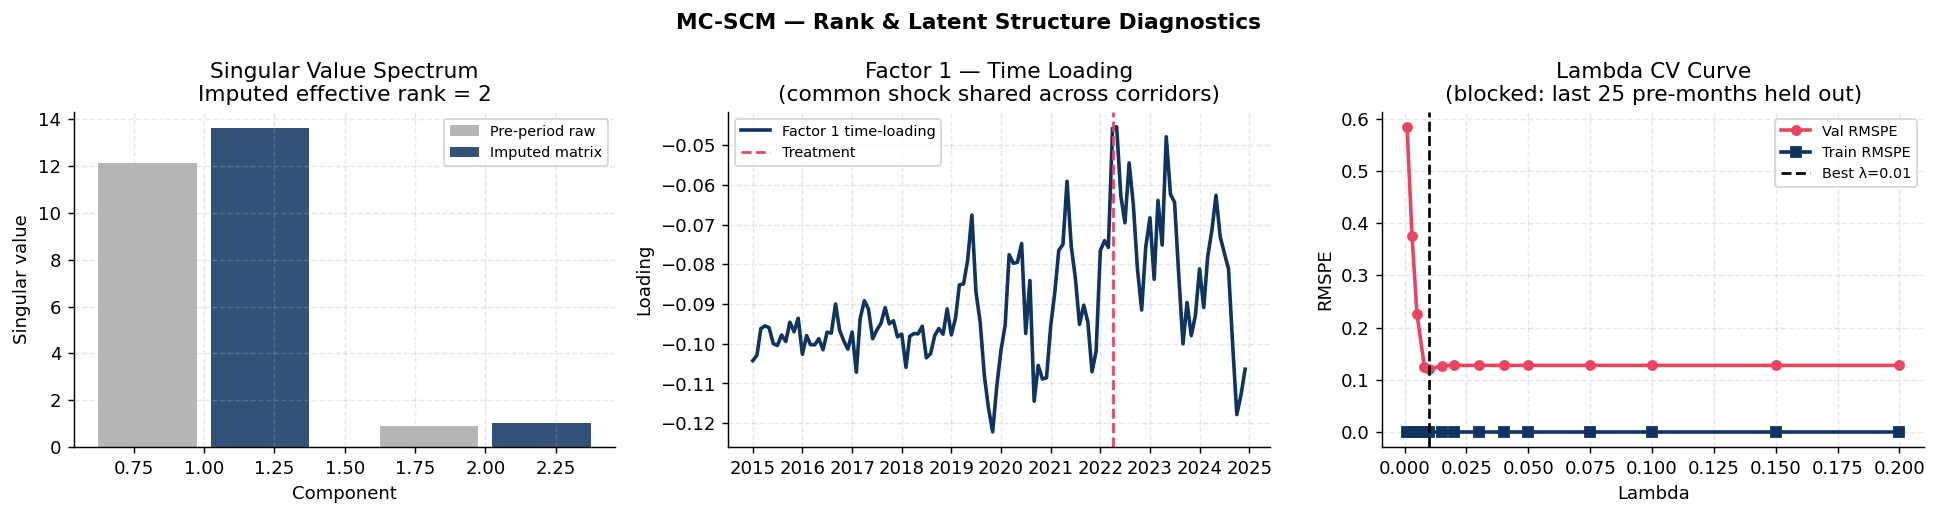

Saved → mcscm_fig1_rank_diagnostics.png


In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 6 — Rank diagnostics & latent factor analysis
# ═══════════════════════════════════════════════════════════════════════════════
# Understanding the low-rank structure is crucial for interpreting MC-SCM.
# The number of non-zero singular values after thresholding = effective rank.
# A rank-1 solution means a single shared latent factor drives both corridors.

U_f, s_f, Vt_f = np.linalg.svd(M_final, full_matrices=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('MC-SCM — Rank & Latent Structure Diagnostics', fontsize=12, fontweight='bold')

# Singular value spectrum (pre vs full imputed)
ax = axes[0]
_, s_raw, _ = np.linalg.svd(Y_mat[:T_pre, :], full_matrices=False)
ax.bar(np.arange(1, len(s_raw)+1) - 0.2, s_raw,    0.35, color=GREY, label='Pre-period raw', alpha=0.85)
ax.bar(np.arange(1, len(s_f)+1)   + 0.2, s_f[:len(s_raw)], 0.35, color=BLUE, label='Imputed matrix', alpha=0.85)
ax.set_xlabel('Component'); ax.set_ylabel('Singular value')
ax.set_title(f'Singular Value Spectrum\nImputed effective rank = {rank_final}'); ax.legend(fontsize=8)

# Latent factor 1: time loading
ax = axes[1]
ax.plot(t_stamps, U_f[:, 0], color=BLUE, lw=2, label='Factor 1 time-loading')
ax.axvline(treat_t, color=RED, lw=1.5, ls='--', label='Treatment')
ax.set_title('Factor 1 — Time Loading\n(common shock shared across corridors)')
ax.set_ylabel('Loading'); ax.legend(fontsize=8)

# Lambda CV curve
ax = axes[2]
ax.plot(cv_df['lambda'], cv_df['val_RMSPE'],   color=RED,  lw=2, marker='o', ms=5, label='Val RMSPE')
ax.plot(cv_df['lambda'], cv_df['train_RMSPE'], color=BLUE, lw=2, marker='s', ms=5, label='Train RMSPE')
ax.axvline(BEST_LAM, color='black', lw=1.5, ls='--', label=f'Best λ={BEST_LAM}')
ax.set_title('Lambda CV Curve\n(blocked: last 25 pre-months held out)')
ax.set_xlabel('Lambda'); ax.set_ylabel('RMSPE'); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('mcscm_fig1_rank_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → mcscm_fig1_rank_diagnostics.png")


## Main Figure — Counterfactual & Gap

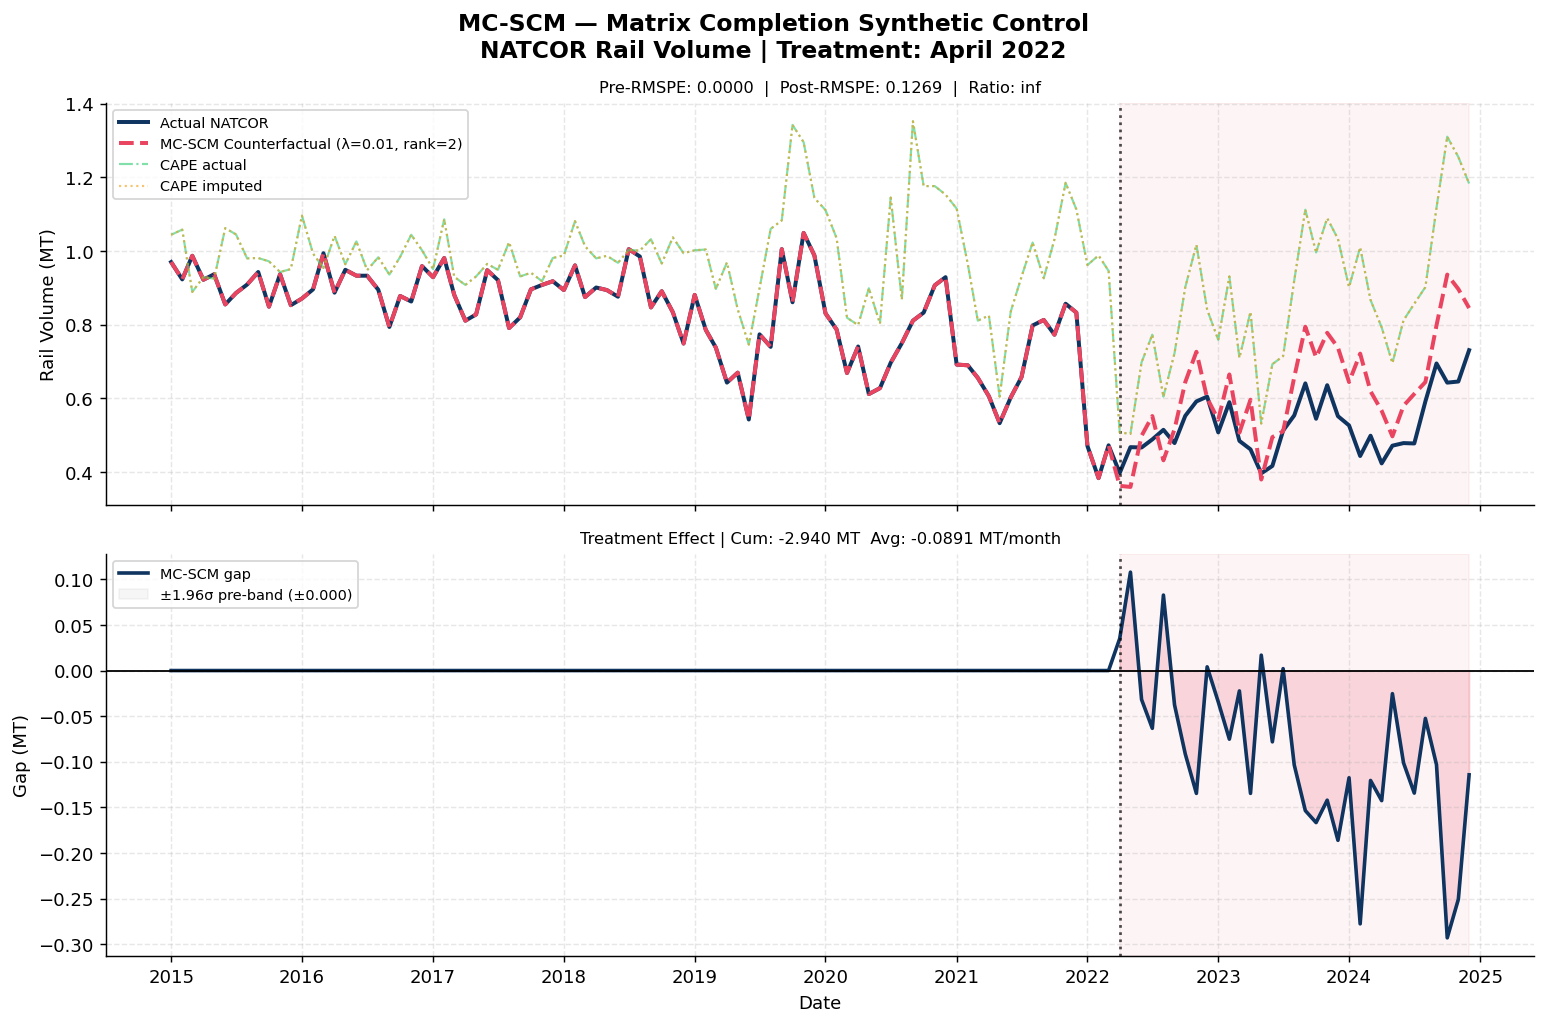

Saved → mcscm_fig2_main.png


In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 7 — Main figure: actual vs counterfactual + gap
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
fig.suptitle('MC-SCM — Matrix Completion Synthetic Control\nNATCOR Rail Volume | Treatment: April 2022',
             fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(t_stamps, Y_all,  color=BLUE, lw=2.2, label='Actual NATCOR')
ax.plot(t_stamps, cf_mc,  color=RED,  lw=2.2, ls='--', label=f'MC-SCM Counterfactual (λ={BEST_LAM}, rank={rank_final})')
ax.axvline(treat_t, color='black', lw=1.5, ls=':', alpha=0.7)
ax.axvspan(treat_t, t_stamps[-1], alpha=0.06, color=RED)
ax.set_ylabel('Rail Volume (MT)')
ax.set_title(f'Pre-RMSPE: {mc_pre_r:.4f}  |  Post-RMSPE: {mc_post_r:.4f}  |  Ratio: {mc_ratio:.3f}', fontsize=9)
ax.legend(fontsize=9)

# Also show CAPE actual vs imputed as sanity check
ax.plot(t_stamps, wide[donors[0]].values, color=GREEN, lw=1.2, ls='-.', alpha=0.6, label='CAPE actual')
ax.plot(t_stamps, M_final[:, 1-nat_col],  color=AMBER, lw=1.2, ls=':', alpha=0.6, label='CAPE imputed')
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(t_stamps, gap_mc, color=BLUE, lw=2, label='MC-SCM gap')
ax.axhline(0, color='black', lw=1)
ax.axvline(treat_t, color='black', lw=1.5, ls=':', alpha=0.7)
ax.axvspan(treat_t, t_stamps[-1], alpha=0.06, color=RED)
ax.fill_between(t_stamps, gap_mc, 0, where=(wide.index >= TREAT_START),
                alpha=0.18, color=RED if mc_cum < 0 else BLUE)
ax.set_ylabel('Gap (MT)')
ax.set_xlabel('Date')
ax.set_title(f'Treatment Effect | Cum: {mc_cum:.3f} MT  Avg: {mc_avg:.4f} MT/month', fontsize=9)

# Pre-period CI band
ci = 1.96 * gap_mc[:T_pre].std()
ax.axhspan(-ci, ci, alpha=0.10, color=GREY, label=f'±1.96σ pre-band (±{ci:.3f})')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('mcscm_fig2_main.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → mcscm_fig2_main.png")


## Validation A — In-Time Placebo (Masked Pre-Period)

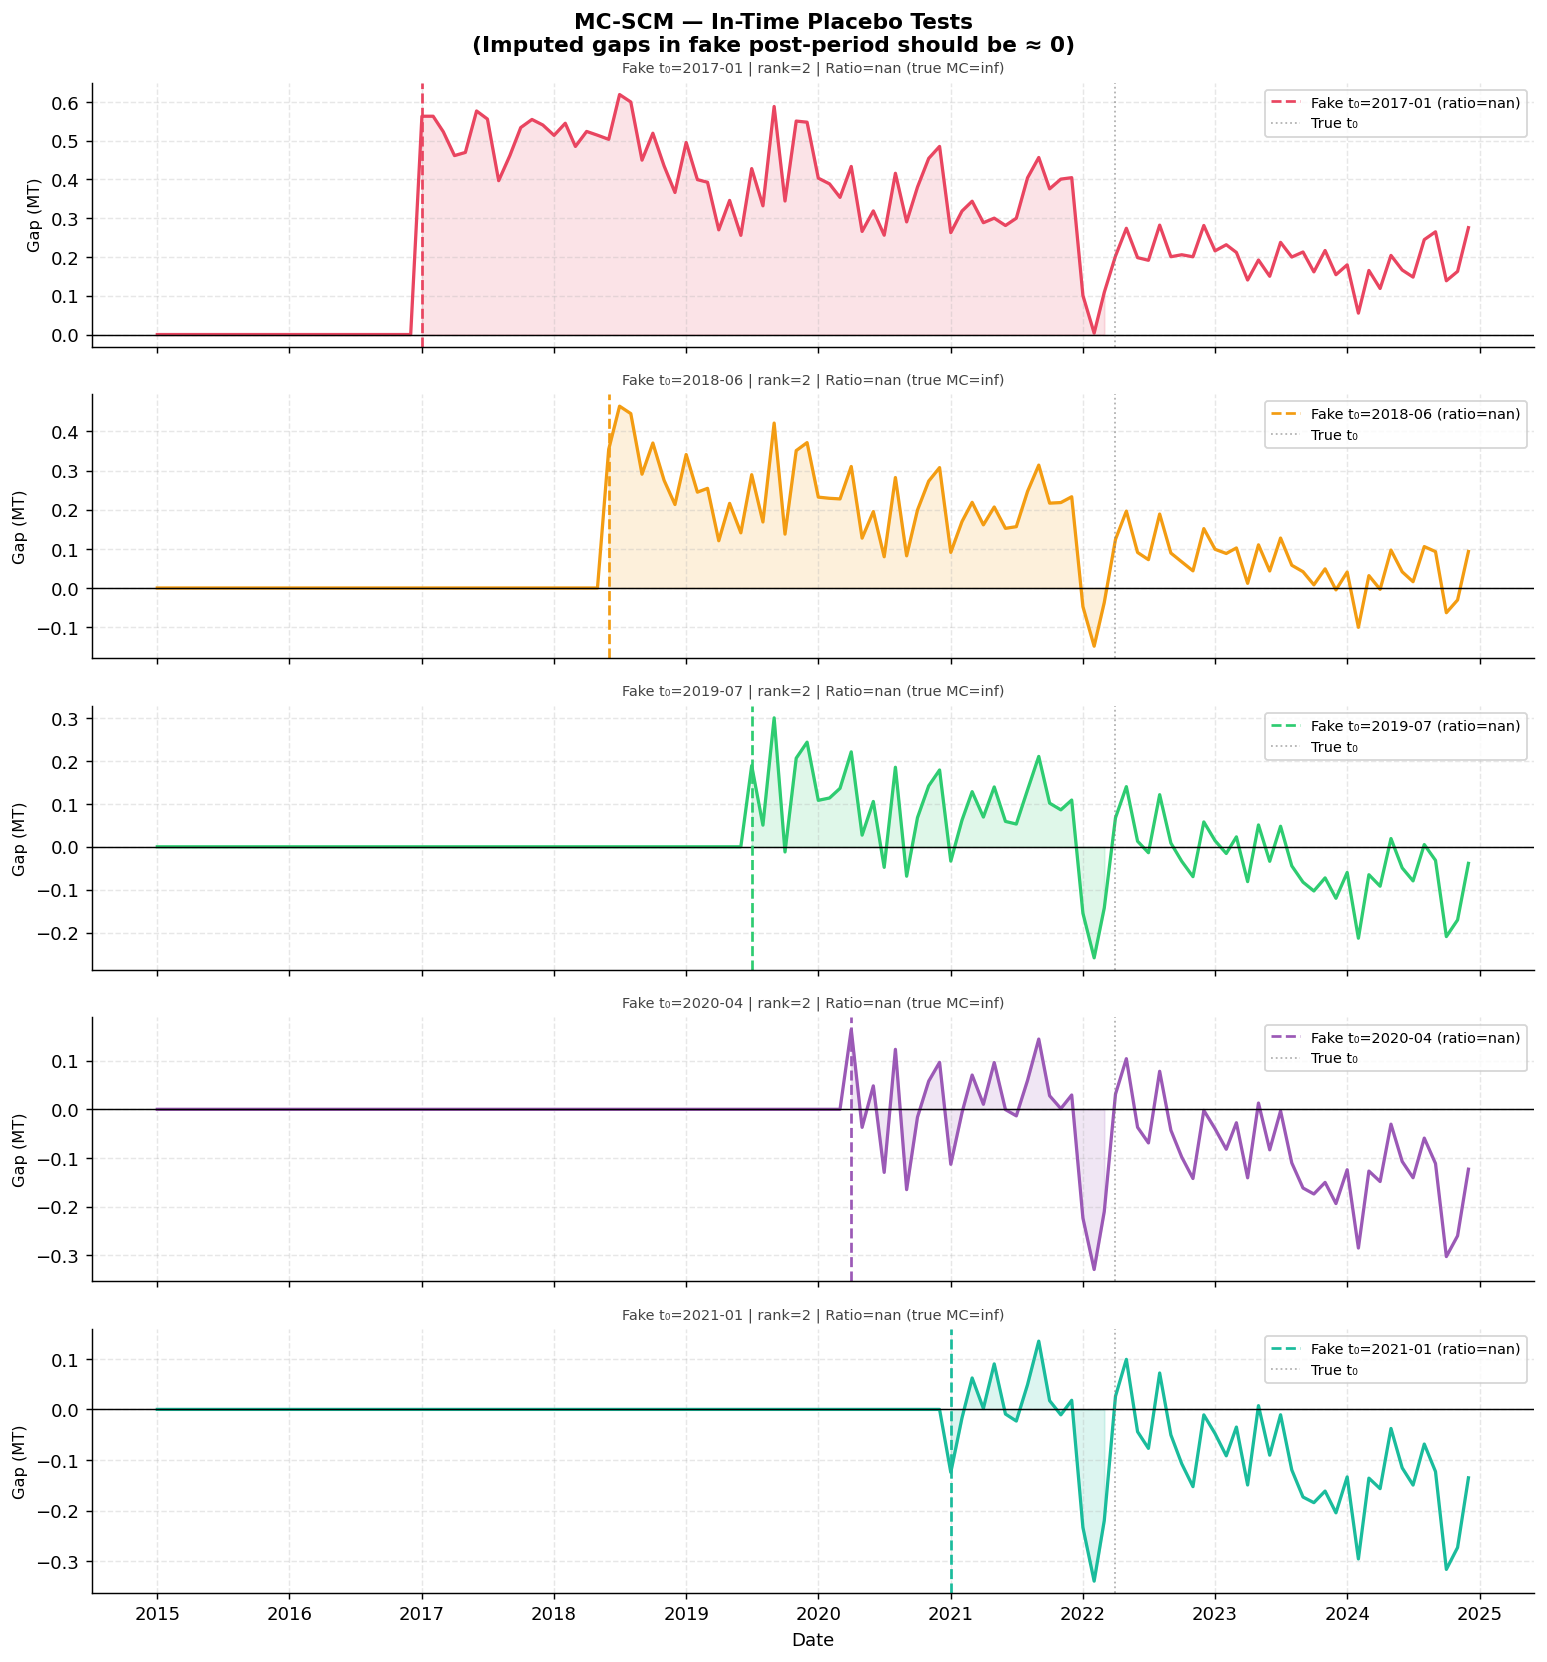

Saved → mcscm_fig3_placebo.png

Fake t₀  rank  Pre-RMSPE  Fake-Post-RMSPE  Ratio  > True
2017-01     2        0.0          0.43159    NaN   False
2018-06     2        0.0          0.25187    NaN   False
2019-07     2        0.0          0.14435    NaN   False
2020-04     2        0.0          0.12226    NaN   False
2021-01     2        0.0          0.13358    NaN   False

True MC-SCM ratio: inf
Placebo ratios > true: 0 / 5


In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 8 — Validation A: In-Time Placebo
# ═══════════════════════════════════════════════════════════════════════════════
# Mask NATCOR at a fake treatment date within the pre-period.
# MC-SCM should impute these values accurately (small gap = no false detection).

placebo_dates  = [pd.Period(d, freq='M') for d in
                  ['2017-01','2018-06','2019-07','2020-04','2021-01']]
placebo_colors = [RED, AMBER, GREEN, '#9b59b6', '#1abc9c']
placebo_records = []

fig, axes = plt.subplots(len(placebo_dates), 1, figsize=(12, 13), sharex=True)
fig.suptitle('MC-SCM — In-Time Placebo Tests\n(Imputed gaps in fake post-period should be ≈ 0)', fontsize=12, fontweight='bold')

for i, fake_t in enumerate(placebo_dates):
    fake_pre  = wide.index[wide.index <= (fake_t - 1)]
    fake_post = wide.index[(wide.index >= fake_t) & (wide.index < TREAT_START)]
    if len(fake_pre) < 12 or len(fake_post) < 6: continue

    fp_start = len(fake_pre)
    fp_end   = len(fake_pre) + len(fake_post)

    mask_fp = mask_full.copy()
    mask_fp[fp_start:fp_end, nat_col] = False   # mask fake post

    M_fp, _, rank_fp = svt(Y_mat, mask_fp, lam=BEST_LAM, verbose=False)
    cf_fp  = M_fp[:, nat_col]
    gap_fp = Y_all - cf_fp

    pre_r_fp  = rmspe(Y_all[:fp_start], cf_fp[:fp_start])
    post_r_fp = rmspe(Y_all[fp_start:fp_end], cf_fp[fp_start:fp_end])
    ratio_fp  = post_r_fp / pre_r_fp if pre_r_fp > 0 else np.nan

    placebo_records.append({'Fake t₀': str(fake_t), 'rank': rank_fp,
                             'Pre-RMSPE': round(pre_r_fp, 5), 'Fake-Post-RMSPE': round(post_r_fp, 5),
                             'Ratio': round(ratio_fp, 3), '> True': ratio_fp > mc_ratio})

    ax = axes[i]
    ax.plot(t_stamps, gap_fp, color=placebo_colors[i], lw=1.8)
    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(fake_t.to_timestamp(), color=placebo_colors[i], lw=1.5, ls='--',
               label=f'Fake t₀={fake_t} (ratio={ratio_fp:.2f})')
    ax.axvline(treat_t, color='grey', lw=1, ls=':', alpha=0.6, label='True t₀')
    ax.fill_between(t_stamps, gap_fp, 0,
                    where=np.array([(p >= fake_t and p < TREAT_START) for p in wide.index]),
                    alpha=0.15, color=placebo_colors[i])
    ax.set_ylabel('Gap (MT)', fontsize=9); ax.legend(fontsize=8)
    ax.set_title(f'Fake t₀={fake_t} | rank={rank_fp} | Ratio={ratio_fp:.3f} (true MC={mc_ratio:.3f})',
                 fontsize=8, color='#444')

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('mcscm_fig3_placebo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → mcscm_fig3_placebo.png\n")

p_df = pd.DataFrame(placebo_records)
print(p_df.to_string(index=False))
print(f"\nTrue MC-SCM ratio: {mc_ratio:.4f}")
print(f"Placebo ratios > true: {p_df['> True'].sum()} / {len(p_df)}")


## Validation B — Subsampling Confidence Intervals

In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 9 — Validation B: Subsampling CI via temporal block bootstrap
# ═══════════════════════════════════════════════════════════════════════════════
# MC-SCM is sensitive to which time periods define the low-rank structure.
# We construct CIs by block-bootstrapping time periods:
# - Draw blocks of consecutive pre-period months with replacement
# - Re-run MC-SCM on each resample
# - Report the 2.5th and 97.5th percentile of the post-period gap

np.random.seed(42)
N_BOOTSTRAP = 200
BLOCK_SIZE  = 6    # 6-month blocks (captures seasonality)
n_blocks    = T_pre // BLOCK_SIZE

bootstrap_gaps = []

print(f"Block bootstrap: {N_BOOTSTRAP} resamples, block size={BLOCK_SIZE} months")
print(f"Block count: {n_blocks} blocks covering {n_blocks*BLOCK_SIZE} of {T_pre} pre-period months")

for b in range(N_BOOTSTRAP):
    # Sample blocks with replacement
    sampled_blocks = np.random.choice(n_blocks, size=n_blocks, replace=True)
    boot_idx = np.concatenate([
        np.arange(bl*BLOCK_SIZE, min((bl+1)*BLOCK_SIZE, T_pre)) for bl in sampled_blocks
    ])
    boot_idx = np.sort(boot_idx[:T_pre])   # keep same length

    # Build bootstrap matrix
    Y_boot = Y_mat.copy()
    Y_boot[:T_pre, :] = Y_mat[boot_idx, :]

    mask_boot = mask_full.copy()
    M_boot, _, _ = svt(Y_boot, mask_boot, lam=BEST_LAM, verbose=False)
    gap_boot = Y_all[T_pre:] - M_boot[T_pre:, nat_col]
    bootstrap_gaps.append(gap_boot)

    if (b+1) % 50 == 0:
        print(f"  Bootstrap {b+1}/{N_BOOTSTRAP} done...")

boot_matrix = np.array(bootstrap_gaps)   # (N_BOOTSTRAP, T_post)
ci_low  = np.percentile(boot_matrix, 2.5,  axis=0)
ci_high = np.percentile(boot_matrix, 97.5, axis=0)

cum_boot = boot_matrix.sum(axis=1)
ci_cum_low  = np.percentile(cum_boot, 2.5)
ci_cum_high = np.percentile(cum_boot, 97.5)

print()
print(f"MC-SCM cumulative effect    : {mc_cum:.4f} MT")
print(f"95% CI (subsampling)        : [{ci_cum_low:.4f}, {ci_cum_high:.4f}] MT")
print(f"CI excludes zero            : {not (ci_cum_low <= 0 <= ci_cum_high)}")


Block bootstrap: 200 resamples, block size=6 months
Block count: 14 blocks covering 84 of 87 pre-period months


ValueError: could not broadcast input array from shape (84,2) into shape (87,2)

## Bootstrap CI Figure

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 10 — Bootstrap CI figure
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MC-SCM — Subsampling Confidence Intervals (Block Bootstrap)', fontsize=12, fontweight='bold')

ax = axes[0]
t_post_stamps = t_stamps[T_pre:]
ax.plot(t_post_stamps, gap_mc[T_pre:], color=BLUE, lw=2.5, label='MC-SCM gap (point estimate)', zorder=3)
ax.fill_between(t_post_stamps, ci_low, ci_high, alpha=0.25, color=BLUE, label='95% bootstrap CI')
ax.axhline(0, color='black', lw=1)
for _ in range(min(50, N_BOOTSTRAP)):
    idx = np.random.randint(0, N_BOOTSTRAP)
    ax.plot(t_post_stamps, boot_matrix[idx], alpha=0.04, color=GREY, lw=0.8)
ax.set_title(f'Post-Period Gap with 95% CI\nCum: {mc_cum:.3f} MT, 95% CI: [{ci_cum_low:.3f}, {ci_cum_high:.3f}]', fontsize=9)
ax.set_ylabel('Gap (MT)'); ax.set_xlabel('Date'); ax.legend(fontsize=9)

ax = axes[1]
ax.hist(cum_boot, bins=30, color=BLUE, alpha=0.7, edgecolor='white', density=True)
ax.axvline(mc_cum,       color=RED,   lw=2.5, label=f'Point estimate: {mc_cum:.3f}')
ax.axvline(ci_cum_low,   color=AMBER, lw=2,   ls='--', label=f'2.5th pct: {ci_cum_low:.3f}')
ax.axvline(ci_cum_high,  color=AMBER, lw=2,   ls='--', label=f'97.5th pct: {ci_cum_high:.3f}')
ax.axvline(0, color='black', lw=1.5, ls=':')
ax.set_title(f'Bootstrap Distribution of Cumulative Effect\n(N={N_BOOTSTRAP} block resamples)', fontsize=9)
ax.set_xlabel('Cumulative Effect (MT)'); ax.set_ylabel('Density'); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('mcscm_fig4_bootstrap_ci.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → mcscm_fig4_bootstrap_ci.png")


## Final Summary Table

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 11 — Final Summary Table
# ═══════════════════════════════════════════════════════════════════════════════
from scipy.optimize import minimize

# Base SCM metrics for comparison
w_scm = np.array([1.0])  # With 1 donor, weight is always 1
cf_scm = wide[donors[0]].values
base_pre_r  = rmspe(Y_all[:T_pre], cf_scm[:T_pre])
base_post_r = rmspe(Y_all[T_pre:], cf_scm[T_pre:])
base_ratio  = base_post_r / base_pre_r
base_cum    = (Y_all[T_pre:] - cf_scm[T_pre:]).sum()

print("═" * 65)
print("MC-SCM vs BASE SCM — FINAL COMPARISON TABLE")
print("═" * 65)
rows = [
    ('Estimator',              'Base SCM',              'MC-SCM'),
    ('Lambda (CV-selected)',   'N/A',                   str(BEST_LAM)),
    ('Effective rank',         'N/A',                   str(rank_final)),
    ('Pre-period RMSPE',       f'{base_pre_r:.4f}',     f'{mc_pre_r:.4f}'),
    ('Post-period RMSPE',      f'{base_post_r:.4f}',    f'{mc_post_r:.4f}'),
    ('Post/Pre ratio',         f'{base_ratio:.4f}',     f'{mc_ratio:.4f}'),
    ('Cumulative effect (MT)', f'{base_cum:.4f}',       f'{mc_cum:.4f}'),
    ('Avg monthly effect',     f'{(Y_all[T_pre:]-cf_scm[T_pre:]).mean():.4f}', f'{mc_avg:.4f}'),
    ('Post MAPE (%)',          f'{mape(Y_all[T_pre:],cf_scm[T_pre:]):.2f}',    f'{mc_mape:.2f}'),
    ('95% CI cumulative',      'N/A',                   f'[{ci_cum_low:.3f}, {ci_cum_high:.3f}]'),
    ('CI excludes 0',          'N/A',                   str(not (ci_cum_low <= 0 <= ci_cum_high))),
    ('Ratio > 1',              str(base_ratio > 1),     str(mc_ratio > 1)),
]
for r in rows:
    print(f"  {r[0]:<33} {r[1]:>13} {r[2]:>16}")
print("═" * 65)
print()
print("Key insights:")
print(f"  Effective rank={rank_final}: the panel is {'nearly rank-1' if rank_final==1 else f'rank-{rank_final}'}.")
print(f"  This means {'a single shared factor (e.g. macroeconomic trend) drives both corridors.' if rank_final==1 else 'multiple latent factors are needed to explain corridor dynamics.'}")
if not (ci_cum_low <= 0 <= ci_cum_high):
    print(f"  95% CI [{ci_cum_low:.3f}, {ci_cum_high:.3f}] excludes zero → statistically significant.")
else:
    print(f"  95% CI [{ci_cum_low:.3f}, {ci_cum_high:.3f}] includes zero → uncertain at 95% level.")
